1. Hasil ekstraksi sensor (RGB+IR+ExG) dikelompokkan **per label** (`Kelas_0.xlsx` s/d `Kelas_3.xlsx`) + gabungan `Semua_Label.xlsx`. Ini isinya fitur mentah aja, belum ada nilai klorofil.
2. Nilai klorofil "aktual" dihitung dari data absorbansi lab pakai rumus Arnon, disimpan di file Excel (`Ground_Truth_Absorbansi_Arnon.xlsx`). File ini cuma jadi **acuan pembanding** waktu evaluasi model, BUKAN untuk diupload ke web buat nyoba prediksi (soalnya isinya udah nilai aktual, bukan fitur sensor).
3. Fitur (R,G,B,IR,ExG) dan nilai Arnon digabung sebentar **di memori** (variabel `df_final`) supaya bisa dipakai buat training+evaluasi LOOCV.
4. File training terdiri dari fitur R,G,B,IR,ExG doang, tidak perlu dicampur sama hasil hitungan Arnon.
5. Scatter plot Aktual vs Prediksi, 2 warna (Aktual = biru, Prediksi = oranye), plus histogram ExG buat lihat sebaran "kehijauan" 16 tanaman.
6. Hasil prediksi Random Forest (fitur + prediksi + metrik + grafik) disimpan di file Excel (`Hasil_Prediksi_RandomForest.xlsx`), terpisah dari file ground truth Arnon.

In [59]:
# Semua library yang dipakai di notebook ini.
# os, glob      -> buat baca-baca folder & file Excel dataset
# joblib        -> buat nyimpen model Random Forest jadi .pkl (biar bisa dipanggil lagi di app.py, gak perlu training ulang)
# pandas, numpy -> olah data tabel/angka
# matplotlib    -> bikin scatter plot & histogram
# sklearn       -> model Random Forest + cara validasi LOOCV + hitung metrik (MAE, MSE, R2, MAPE)
# openpyxl      -> bikin file Excel hasil akhir yang rapi (ada judul, warna header, gambar ditempel)
import os
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)

from openpyxl import Workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Lokasi folder & file yang dipakai
FOLDER_DATASET_ASLI = r"c:\Users\Balqoz\skripsiku\Dataset Asli"                 
FILE_ABSORBANSI     = r"C:\Users\Balqoz\skripsiku\Data Absorbansi\Latihan UV Vis 21 Juli 2022.xlsx"
FOLDER_OUTPUT       = r"C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi_new"    
os.makedirs(FOLDER_OUTPUT, exist_ok=True)

# Pola regex buat "membaca" teks mentah dari sensor Arduino, contoh: "R=132 G=132.20 B=79.36 70%"
POLA_REGEX = r"R=\s*([\d.]+)\s*G=\s*([\d.]+)\s*B=\s*([\d.]+)\s*(\d+)\s*%"
FITUR = ["R", "G", "B", "IR", "ExG"]              # 5 fitur yang dipakai buat training/prediksi
TARGETS = ["Klorofil_A", "Klorofil_B", "Total_Klorofil"]  # 3 target yang mau diprediksi


## `ekstrak_satu_file`
Fungsi bantu ekstraksi 1 file mentah (dipanggil otomatis oleh proses_semua_file).

In [60]:
def ekstrak_satu_file(file_path: str, label: int, tanaman_ke: int) -> pd.DataFrame:
    """Baca 1 file mentah punya 1 tanaman, terus tarik nilai R,G,B,IR dari
    teks sensor pakai regex, terus itung ExG-nya. Hasilnya per BARIS bacaan
    sensor (belum dirata-rata per tanaman -- rata-rata baru dilakukan nanti
    kalau perlu, misal saat prediksi lewat web)."""
    df_raw = pd.read_excel(file_path, header=None)

    # Tarik 4 angka (R,G,B,IR) dari tiap baris teks mentah
    hasil = df_raw[0].astype(str).str.extract(POLA_REGEX)
    hasil.columns = ["R", "G", "B", "IR"]
    hasil = hasil.apply(pd.to_numeric, errors="coerce")
    hasil.dropna(inplace=True)  # buang baris yang gagal terbaca (format aneh/rusak)

    # ExG = 2G - R - B -> indeks buat nangkep "kehijauan" daun, dihitung dari RGB mentah
    hasil["ExG"] = (2 * hasil["G"]) - hasil["R"] - hasil["B"]

    hasil["Perlakuan"] = label        # label perlakuan pupuk (0-3)
    hasil["Tanaman_Ke"] = tanaman_ke  # tanaman ulangan ke berapa dalam label itu
    return hasil


## `proses_semua_file`
Ekstraksi seluruh file, dikelompokkan per label (Kelas_0..3.xlsx + Semua_Label.xlsx)

In [61]:
def proses_semua_file():
    """Loop semua file HHxy.xlsx di folder Dataset Asli, ekstrak RGB+IR+ExG-nya,
    lalu kelompokkan hasilnya per label (0-3) dan simpan sebagai Kelas_0..3.xlsx
    + satu file gabungan Semua_Label.xlsx. Selain itu bikin juga tabel ringkasan
    (rata-rata per tanaman, 16 baris) yang dipakai buat langkah training nanti."""
    print("=" * 70)
    print("Ekstraksi fitur sensor (RGB, IR, ExG) dari 16 file mentah, dikelompokkan per label")
    print("=" * 70)

    files = sorted(glob.glob(os.path.join(FOLDER_DATASET_ASLI, "HH*.xlsx")))
    print(f"Ditemukan {len(files)} file: {[os.path.basename(f) for f in files]}\n")

    per_label = {0: [], 1: [], 2: [], 3: []}
    daftar_ringkasan = []

    for file_path in files:
        nama = os.path.splitext(os.path.basename(file_path))[0]
        label = int(nama[2])     # digit ke-3 nama file = label perlakuan
        ulangan = int(nama[3])   # digit ke-4 nama file = tanaman ulangan ke berapa

        detail = ekstrak_satu_file(file_path, label, ulangan)
        per_label[label].append(detail)

        # 1 tanaman diwakili 1 baris rata-rata dari semua bacaan sensornya
        ringkasan = detail[["R", "G", "B", "IR", "ExG"]].mean(numeric_only=True).to_dict()
        ringkasan["Perlakuan"] = label
        ringkasan["Tanaman_Ke"] = ulangan
        ringkasan["Nama_File"] = nama
        daftar_ringkasan.append(ringkasan)

        print(f"  [{nama}] label={label}, tanaman ke-{ulangan}, "
              f"{len(detail)} baris bacaan sensor valid -> rata-rata ExG={ringkasan['ExG']:.2f}")

    # --- Simpan 1 file per label (gabungan semua baris tanaman dalam label itu) ---
    semua_label_list = []
    for label, daftar_df in per_label.items():
        df_kelas = pd.concat(daftar_df, ignore_index=True)
        df_kelas = df_kelas[["R", "G", "B", "IR", "ExG", "Perlakuan", "Tanaman_Ke"]]
        path_kelas = os.path.join(FOLDER_OUTPUT, f"Kelas_{label}.xlsx")
        df_kelas.to_excel(path_kelas, index=False)
        semua_label_list.append(df_kelas)
        print(f"\n  >> Kelas_{label}.xlsx tersimpan ({len(df_kelas)} baris, "
              f"gabungan {len(daftar_df)} tanaman)")

    # --- Simpan 1 file gabungan semua label (buat cek cepat / dokumentasi) ---
    df_semua_label = pd.concat(semua_label_list, ignore_index=True)
    path_semua = os.path.join(FOLDER_OUTPUT, "Semua_Label.xlsx")
    df_semua_label.to_excel(path_semua, index=False)
    print(f"\n  >> Semua_Label.xlsx tersimpan ({len(df_semua_label)} baris total)\n")

    # --- Ringkasan rata-rata per tanaman (16 baris) -- INI file fitur murni
    # (R,G,B,IR,ExG doang, tanpa nilai klorofil) yang dipakai buat training,
    # dan juga file yang aman buat dicoba upload-predict di web nanti.
    df_fitur = pd.DataFrame(daftar_ringkasan)
    df_fitur = df_fitur[["Nama_File", "Perlakuan", "Tanaman_Ke", "R", "G", "B", "IR", "ExG"]]
    path_fitur = os.path.join(FOLDER_OUTPUT, "Dataset_Fitur_16_Tanaman.xlsx")
    df_fitur.to_excel(path_fitur, index=False)
    print(f">> Ringkasan fitur 16 tanaman (fitur doang, tanpa target) tersimpan di: {path_fitur}\n")
    return df_fitur


In [62]:
# Menampilkan hasil ekstraksi semua file
df_fitur = proses_semua_file()

Ekstraksi fitur sensor (RGB, IR, ExG) dari 16 file mentah, dikelompokkan per label
Ditemukan 16 file: ['HH01.xlsx', 'HH02.xlsx', 'HH03.xlsx', 'HH04.xlsx', 'HH11.xlsx', 'HH12.xlsx', 'HH13.xlsx', 'HH14.xlsx', 'HH21.xlsx', 'HH22.xlsx', 'HH23.xlsx', 'HH24.xlsx', 'HH31.xlsx', 'HH32.xlsx', 'HH33.xlsx', 'HH34.xlsx']

  [HH01] label=0, tanaman ke-1, 75 baris bacaan sensor valid -> rata-rata ExG=35.54
  [HH02] label=0, tanaman ke-2, 101 baris bacaan sensor valid -> rata-rata ExG=40.06
  [HH03] label=0, tanaman ke-3, 78 baris bacaan sensor valid -> rata-rata ExG=40.05
  [HH04] label=0, tanaman ke-4, 72 baris bacaan sensor valid -> rata-rata ExG=49.73
  [HH11] label=1, tanaman ke-1, 82 baris bacaan sensor valid -> rata-rata ExG=38.29
  [HH12] label=1, tanaman ke-2, 75 baris bacaan sensor valid -> rata-rata ExG=37.77
  [HH13] label=1, tanaman ke-3, 89 baris bacaan sensor valid -> rata-rata ExG=36.23
  [HH14] label=1, tanaman ke-4, 122 baris bacaan sensor valid -> rata-rata ExG=33.73
  [HH21] label

## `hitung_ground_truth_klorofil`
Ini yang menghitung nilai klorofil "aktual" (acuan pembanding), langsung dari data absorbansi lab asli pakai rumus Arnon (1949) -- BUKAN dari sensor RGB/IR. Hasilnya disimpan di file Excel tersendiri, dan file ini **tidak dipakai sebagai input buat upload-predict di web**, cuma jadi pembanding waktu ngukur akurasi model.


In [63]:
def hitung_ground_truth_klorofil():
    """Hitung nilai klorofil aktual (Chl a, Chl b, Total) dari data absorbansi
    UV-Vis Spektrofotometer yang asli, pakai rumus Arnon (1949). Ini nilai
    yang JADI PEMBANDING waktu evaluasi model -- bukan hasil sensor, bukan
    hasil tebakan model, tapi hasil pengukuran kimia langsung di lab."""
    print("=" * 70)
    print("Menghitung klorofil aktual dari absorbansi lab asli (rumus Arnon)")
    print("=" * 70)

    df_abs = pd.read_excel(FILE_ABSORBANSI)
    # Alat spektrofotometer di lab scan tiap kelipatan 5nm, jadi panjang gelombang
    # 663nm dan 669nm (yang dipakai rumus Arnon) didekati pakai kolom terdekat
    # yang ada di data (665nm dan 670nm).
    A645 = df_abs[645].iloc[0:4].values
    A663_proxy = df_abs[665].iloc[0:4].values     # proksi buat 663nm
    A665 = df_abs[665].iloc[0:4].values
    A669_proxy = df_abs[670].iloc[0:4].values     # proksi buat 669nm

    df_gt = pd.DataFrame({
        "Perlakuan": [0, 1, 2, 3],
        "A645": A645,
        "A663_proxy(665nm)": A663_proxy,
        "A665": A665,
        "A669_proxy(670nm)": A669_proxy,
    })
    # Rumus Arnon (1949) -- persamaan standar buat hitung kadar klorofil dari absorbansi
    df_gt["Klorofil_A"] = 12.7 * df_gt["A663_proxy(665nm)"] - 2.69 * df_gt["A645"]
    df_gt["Klorofil_B"] = 22.9 * df_gt["A645"] - 4.68 * df_gt["A669_proxy(670nm)"]
    df_gt["Total_Klorofil"] = 20.2 * df_gt["A645"] + 8.02 * df_gt["A665"]

    # File ini disimpan TERSENDIRI dan tidak digabung ke file fitur, karena
    # tujuannya cuma jadi acuan/pembanding, bukan bahan upload buat prediksi.
    path_gt = os.path.join(FOLDER_OUTPUT, "Ground_Truth_Absorbansi_Arnon.xlsx")
    df_gt.to_excel(path_gt, index=False)
    print(df_gt.to_string(index=False))
    print(f"\n>> File acuan klorofil aktual (Arnon) tersimpan di: {path_gt}\n")
    return df_gt


In [64]:
# Menghitung hasil ground truth klorofil dari absorbansi
df_gt = hitung_ground_truth_klorofil()

Menghitung klorofil aktual dari absorbansi lab asli (rumus Arnon)
 Perlakuan   A645  A663_proxy(665nm)   A665  A669_proxy(670nm)  Klorofil_A  Klorofil_B  Total_Klorofil
         0 0.6494             0.6247 0.6247             0.6179    6.186804   11.979488       18.127974
         1 0.6959             0.6780 0.6780             0.6719    6.738629   12.791618       19.494740
         2 0.6960             0.6781 0.6781             0.6720    6.739630   12.793440       19.497562
         3 0.7056             0.6888 0.6888             0.6822    6.849696   12.965544       19.777296

>> File acuan klorofil aktual (Arnon) tersimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi_new\Ground_Truth_Absorbansi_Arnon.xlsx



## `gabungkan_dataset_final`
Gabung fitur (16 tanaman) dengan nilai klorofil aktual dari Arnon, tapi **cuma di memori Python** (variabel `df_final`), TIDAK disimpan lagi jadi file Excel terpisah. Alasannya: kata Bu Ely, file yang boleh diupload buat training/prediksi cukup fitur R,G,B,IR,ExG saja -- kalau hitungan Arnon ikut disimpan di file yang sama, nanti bisa disalahartikan seolah nilai itu juga harus diupload, padahal itu cuma pembanding.


In [65]:
def gabungkan_dataset_final(df_fitur, df_gt):
    """Gabung tabel fitur (16 tanaman, R/G/B/IR/ExG) dengan tabel klorofil
    aktual dari Arnon (4 baris, 1 per label), cukup di memori aja. Hasilnya
    dipakai buat training + evaluasi LOOCV di langkah berikutnya. Sengaja
    TIDAK di-export ke Excel lagi, biar tidak ada file yang isinya fitur
    tercampur target -- yang boleh diupload ke web cuma fiturnya saja."""
    print("=" * 70)
    print("Gabung fitur (16 tanaman) + klorofil aktual Arnon (per label) -- di memori saja")
    print("=" * 70)

    df_final = df_fitur.merge(df_gt[["Perlakuan"] + TARGETS], on="Perlakuan", how="left")
    kolom_akhir = ["Nama_File", "Perlakuan", "Tanaman_Ke"] + FITUR + TARGETS
    df_final = df_final[kolom_akhir]

    print(df_final.to_string(index=False))
    print("\n>> Dataset gabungan ini cuma dipakai buat training & evaluasi di notebook ini,")
    print("   TIDAK disimpan jadi file Excel terpisah (biar tidak dipakai keliru sebagai bahan upload).\n")
    return df_final


In [66]:
# Menggabung fitur + klorofil aktual (Arnon) di memori, buat lanjut training & evaluasi
df_final = gabungkan_dataset_final(df_fitur, df_gt)


Gabung fitur (16 tanaman) + klorofil aktual Arnon (per label) -- di memori saja
Nama_File  Perlakuan  Tanaman_Ke          R          G          B        IR       ExG  Klorofil_A  Klorofil_B  Total_Klorofil
     HH01          0           1 148.693333 150.792000 117.351200 71.880000 35.539467    6.186804   11.979488       18.127974
     HH02          0           2 143.643564 147.645545 111.587129 89.643564 40.060396    6.186804   11.979488       18.127974
     HH03          0           3 143.641026 146.476923 109.260000 69.858974 40.052821    6.186804   11.979488       18.127974
     HH04          0           4 130.722222 136.500000  92.551389 68.111111 49.726389    6.186804   11.979488       18.127974
     HH11          1           1 151.890244 152.248780 114.314146 75.865854 38.293171    6.738629   12.791618       19.494740
     HH12          1           2 146.933333 150.376000 116.044267 74.973333 37.774400    6.738629   12.791618       19.494740
     HH13          1           3 145.5

## `training_dan_evaluasi_loocv`
Training Random Forest pakai skema LOOCV (Leave-One-Out Cross-Validation): tiap 1 sampel gantian jadi "data ujian", dilatih dari 15 sampel sisanya. Diulang sampai semua 16 sampel kebagian jadi data ujian, terus dihitung metriknya (MAE, MSE, R2, MAPE). Ini dilakukan 3x sendiri-sendiri buat Klorofil A, Klorofil B, dan Total Klorofil.


In [67]:
def training_dan_evaluasi_loocv(df_final):
    """Training & evaluasi Random Forest pakai LOOCV. Karena cuma ada 16
    sampel, LOOCV dipilih karena bisa memanfaatkan tiap sampel jadi data uji
    tanpa mengorbankan data training (beda dengan split train-test biasa yang
    bakal buang sebagian data buat testing doang)."""
    print("=" * 70)
    print("Training Random Forest dengan LOOCV (per target klorofil)")
    print("=" * 70)

    X = df_final[FITUR].values
    loo = LeaveOneOut()

    hasil_prediksi = {}
    tabel_metrik = []

    for target in TARGETS:
        y = df_final[target].values
        preds = np.zeros(len(y))

        # Tiap iterasi: 1 sampel jadi "ujian" (test_idx), sisanya buat latihan (train_idx).
        # Modelnya dibuat baru tiap iterasi supaya benar-benar tidak pernah
        # "menyontek" dari sampel yang sedang diuji.
        for train_idx, test_idx in loo.split(X):
            model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
            model.fit(X[train_idx], y[train_idx])
            preds[test_idx] = model.predict(X[test_idx])

        hasil_prediksi[target] = preds

        df_pred = df_final.copy()

        df_pred[f"Pred_{target}"] = preds

        hasil_label = (
            df_pred
            .groupby("Perlakuan", as_index=False)
            .agg({
                target: "mean",
                f"Pred_{target}": "mean"
            })
        )

        print(f"\nHasil rata-rata per perlakuan ({target})")
        print(hasil_label)

        mae = mean_absolute_error(y, preds)
        mse = mean_squared_error(y, preds)
        r2 = r2_score(y, preds)
        mape = mean_absolute_percentage_error(y, preds) * 100
        tabel_metrik.append({"Target": target, "MAE": mae, "MSE": mse, "R2": r2, "MAPE (%)": mape})

        print(f"\n-------- {target.upper()} --------")
        print(f"R2 Score : {r2:.4f}")
        print(f"MAE      : {mae:.4f}")
        print(f"MSE      : {mse:.4f}")
        print(f"MAPE     : {mape:.2f}%")

    df_metrik = pd.DataFrame(tabel_metrik)
    print("\n" + "=" * 70)
    print("RINGKASAN METRIK EVALUASI (LOOCV)")
    print("=" * 70)
    print(df_metrik.to_string(index=False))
    return hasil_prediksi, df_metrik, df_pred


In [68]:
# Jalankan training + evaluasi LOOCV buat 3 target klorofil sekaligus
hasil_prediksi, df_metrik, df_pred = training_dan_evaluasi_loocv(df_final)


Training Random Forest dengan LOOCV (per target klorofil)

Hasil rata-rata per perlakuan (Klorofil_A)
   Perlakuan  Klorofil_A  Pred_Klorofil_A
0          0    6.186804         6.643859
1          1    6.738629         6.648169
2          2    6.739630         6.628622
3          3    6.849696         6.473676

-------- KLOROFIL_A --------
R2 Score : -0.5065
MAE      : 0.2586
MSE      : 0.1011
MAPE     : 3.97%

Hasil rata-rata per perlakuan (Klorofil_B)
   Perlakuan  Klorofil_B  Pred_Klorofil_B
0          0   11.979488        12.655914
1          1   12.791618        12.647698
2          2   12.793440        12.637346
3          3   12.965544        12.412268

-------- KLOROFIL_B --------
R2 Score : -0.5062
MAE      : 0.3824
MSE      : 0.2216
MAPE     : 3.06%

Hasil rata-rata per perlakuan (Total_Klorofil)
   Perlakuan  Total_Klorofil  Pred_Total_Klorofil
0          0       18.127974            19.259703
1          1       19.494740            19.289405
2          2       19.497562    

In [69]:
TARGETS = ["Klorofil_A", "Klorofil_B", "Total_Klorofil", "Pred_Klorofil_A", "Pred_Klorofil_B", "Pred_Total_Klorofil"]  # 6 target yang mau diprediksi

print(TARGETS)

['Klorofil_A', 'Klorofil_B', 'Total_Klorofil', 'Pred_Klorofil_A', 'Pred_Klorofil_B', 'Pred_Total_Klorofil']


In [70]:
print(df_final.to_string(index=False))

Nama_File  Perlakuan  Tanaman_Ke          R          G          B        IR       ExG  Klorofil_A  Klorofil_B  Total_Klorofil
     HH01          0           1 148.693333 150.792000 117.351200 71.880000 35.539467    6.186804   11.979488       18.127974
     HH02          0           2 143.643564 147.645545 111.587129 89.643564 40.060396    6.186804   11.979488       18.127974
     HH03          0           3 143.641026 146.476923 109.260000 69.858974 40.052821    6.186804   11.979488       18.127974
     HH04          0           4 130.722222 136.500000  92.551389 68.111111 49.726389    6.186804   11.979488       18.127974
     HH11          1           1 151.890244 152.248780 114.314146 75.865854 38.293171    6.738629   12.791618       19.494740
     HH12          1           2 146.933333 150.376000 116.044267 74.973333 37.774400    6.738629   12.791618       19.494740
     HH13          1           3 145.550562 148.325843 114.868989 68.685393 36.232135    6.738629   12.791618       19

In [71]:
df_pred 

,Nama_File,Perlakuan,Tanaman_Ke,R,G,B,IR,ExG,Klorofil_A,Klorofil_B,Total_Klorofil,Pred_Total_Klorofil
0,HH01,0,1,148.693333,150.792000,117.351200,71.880000,35.539467,6.186804,11.979488,18.127974,19.510251
1,HH02,0,2,143.643564,147.645545,111.587129,89.643564,40.060396,6.186804,11.979488,18.127974,19.196917
2,HH03,0,3,143.641026,146.476923,109.260000,69.858974,40.052821,6.186804,11.979488,18.127974,19.019443
3,HH04,0,4,130.722222,136.500000,92.551389,68.111111,49.726389,6.186804,11.979488,18.127974,19.312200
4,HH11,1,1,151.890244,152.248780,114.314146,75.865854,38.293171,6.738629,12.791618,19.494740,19.318762
5,HH12,1,2,146.933333,150.376000,116.044267,74.973333,37.774400,6.738629,12.791618,19.494740,19.349310
6,HH13,1,3,145.550562,148.325843,114.868989,68.685393,36.232135,6.738629,12.791618,19.494740,19.209571
7,HH14,1,4,153.057377,154.822951,122.856721,70.090164,33.731803,6.738629,12.791618,19.494740,19.279975
8,HH21,2,1,152.852941,154.929412,123.797059,91.225490,33.208824,6.739630,12.793440,19.497562,19.348717
9,HH22,2,2,150.090909,153.772727,124.913182,93.681818,32.541364,6.739630,12.793440,19.497562,19.280746


In [72]:
df_hasil = df_final.copy()
# df_hasil = pd.concat([df_hasil, df_pred], axis=1)

for target in TARGETS:
    # map "Pred_*" names to base target keys in hasil_prediksi
    key = target
    if key.startswith("Pred_"):
        key = key.replace("Pred_", "")
        col_name = target
    else:
        col_name = f"Pred_{target}"
    df_hasil[col_name] = hasil_prediksi.get(key, np.nan)

    # buat DataFrame bersih supaya tidak kena masalah kolom duplikat saat groupby
    df_group = pd.DataFrame({
        "Perlakuan": df_final["Perlakuan"],
        "Klorofil_A": df_final["Klorofil_A"],
        "Pred_Klorofil_A": hasil_prediksi["Klorofil_A"],
        "Klorofil_B": df_final["Klorofil_B"],
        "Pred_Klorofil_B": hasil_prediksi["Klorofil_B"],
        "Total_Klorofil": df_final["Total_Klorofil"],
        "Pred_Total_Klorofil": hasil_prediksi["Total_Klorofil"],
    })

    hasil_per_label = df_group.groupby("Perlakuan", as_index=False).mean()

print(hasil_per_label)

   Perlakuan  Klorofil_A  Pred_Klorofil_A  Klorofil_B  Pred_Klorofil_B  \
0          0    6.186804         6.643859   11.979488        12.655914   
1          1    6.738629         6.648169   12.791618        12.647698   
2          2    6.739630         6.628622   12.793440        12.637346   
3          3    6.849696         6.473676   12.965544        12.412268   

   Total_Klorofil  Pred_Total_Klorofil  
0       18.127974            19.259703  
1       19.494740            19.289405  
2       19.497562            19.228047  
3       19.777296            18.862868  


In [73]:
df_hasil

,Nama_File,Perlakuan,Tanaman_Ke,R,G,B,IR,ExG,Klorofil_A,Klorofil_B,Total_Klorofil,Pred_Klorofil_A,Pred_Klorofil_B,Pred_Total_Klorofil
0,HH01,0,1,148.693333,150.792000,117.351200,71.880000,35.539467,6.186804,11.979488,18.127974,6.744673,12.801189,19.510251
1,HH02,0,2,143.643564,147.645545,111.587129,89.643564,40.060396,6.186804,11.979488,18.127974,6.629750,12.635892,19.196917
2,HH03,0,3,143.641026,146.476923,109.260000,69.858974,40.052821,6.186804,11.979488,18.127974,6.538071,12.519162,19.019443
3,HH04,0,4,130.722222,136.500000,92.551389,68.111111,49.726389,6.186804,11.979488,18.127974,6.662940,12.667413,19.312200
4,HH11,1,1,151.890244,152.248780,114.314146,75.865854,38.293171,6.738629,12.791618,19.494740,6.637545,12.659466,19.318762
5,HH12,1,2,146.933333,150.376000,116.044267,74.973333,37.774400,6.738629,12.791618,19.494740,6.657707,12.687389,19.349310
6,HH13,1,3,145.550562,148.325843,114.868989,68.685393,36.232135,6.738629,12.791618,19.494740,6.634293,12.568647,19.209571
7,HH14,1,4,153.057377,154.822951,122.856721,70.090164,33.731803,6.738629,12.791618,19.494740,6.663130,12.675287,19.279975
8,HH21,2,1,152.852941,154.929412,123.797059,91.225490,33.208824,6.739630,12.793440,19.497562,6.674031,12.704825,19.348717
9,HH22,2,2,150.090909,153.772727,124.913182,93.681818,32.541364,6.739630,12.793440,19.497562,6.641022,12.664637,19.280746


In [74]:
# Simpan DataFrame ke file Excel
output_file = "Hasil_Ekstraksi_new/hasil_prediksi_random_forest.xlsx"

df_hasil.to_excel(output_file, index=False)

print(f"Data berhasil disimpan ke '{output_file}'")

Data berhasil disimpan ke 'Hasil_Ekstraksi_new/hasil_prediksi_random_forest.xlsx'


## `buat_scatter_plot`
Scatter plot buat lihat sedekat mana prediksi Random Forest sama nilai aktual (Arnon), per sampel tanaman. Aktual = titik biru, Prediksi = titik oranye -- kalau dua titik itu deket/nyambung berarti model nebaknya bagus.


In [75]:
df_hasil

,Nama_File,Perlakuan,Tanaman_Ke,R,G,B,IR,ExG,Klorofil_A,Klorofil_B,Total_Klorofil,Pred_Klorofil_A,Pred_Klorofil_B,Pred_Total_Klorofil
0,HH01,0,1,148.693333,150.792000,117.351200,71.880000,35.539467,6.186804,11.979488,18.127974,6.744673,12.801189,19.510251
1,HH02,0,2,143.643564,147.645545,111.587129,89.643564,40.060396,6.186804,11.979488,18.127974,6.629750,12.635892,19.196917
2,HH03,0,3,143.641026,146.476923,109.260000,69.858974,40.052821,6.186804,11.979488,18.127974,6.538071,12.519162,19.019443
3,HH04,0,4,130.722222,136.500000,92.551389,68.111111,49.726389,6.186804,11.979488,18.127974,6.662940,12.667413,19.312200
4,HH11,1,1,151.890244,152.248780,114.314146,75.865854,38.293171,6.738629,12.791618,19.494740,6.637545,12.659466,19.318762
5,HH12,1,2,146.933333,150.376000,116.044267,74.973333,37.774400,6.738629,12.791618,19.494740,6.657707,12.687389,19.349310
6,HH13,1,3,145.550562,148.325843,114.868989,68.685393,36.232135,6.738629,12.791618,19.494740,6.634293,12.568647,19.209571
7,HH14,1,4,153.057377,154.822951,122.856721,70.090164,33.731803,6.738629,12.791618,19.494740,6.663130,12.675287,19.279975
8,HH21,2,1,152.852941,154.929412,123.797059,91.225490,33.208824,6.739630,12.793440,19.497562,6.674031,12.704825,19.348717
9,HH22,2,2,150.090909,153.772727,124.913182,93.681818,32.541364,6.739630,12.793440,19.497562,6.641022,12.664637,19.280746


Scatter Plot Aktual vs Prediksi per Label

Rata-rata tiap label:
   Perlakuan  Klorofil_A  Pred_Klorofil_A  Klorofil_B  Pred_Klorofil_B  \
0          0    6.186804         6.643859   11.979488        12.655914   
1          1    6.738629         6.648169   12.791618        12.647698   
2          2    6.739630         6.628622   12.793440        12.637346   
3          3    6.849696         6.473676   12.965544        12.412268   

   Total_Klorofil  Pred_Total_Klorofil  
0       18.127974            19.259703  
1       19.494740            19.289405  
2       19.497562            19.228047  
3       19.777296            18.862868  


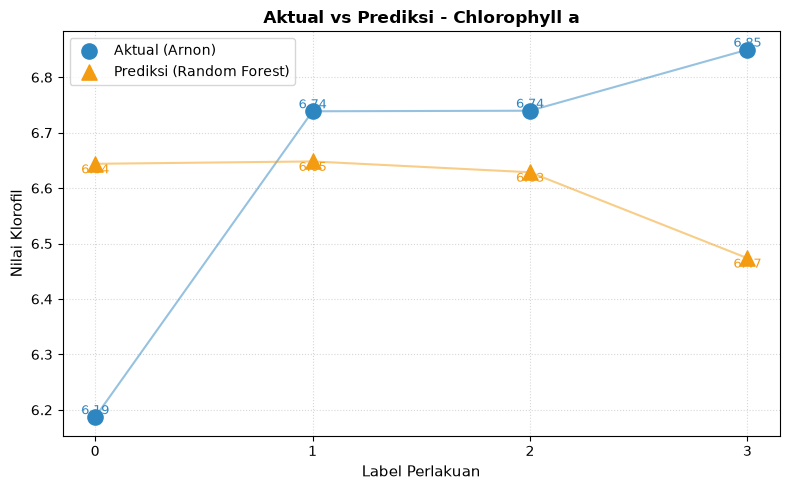

Klorofil_A disimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi_new\Scatter_PerLabel_Klorofil_A.png


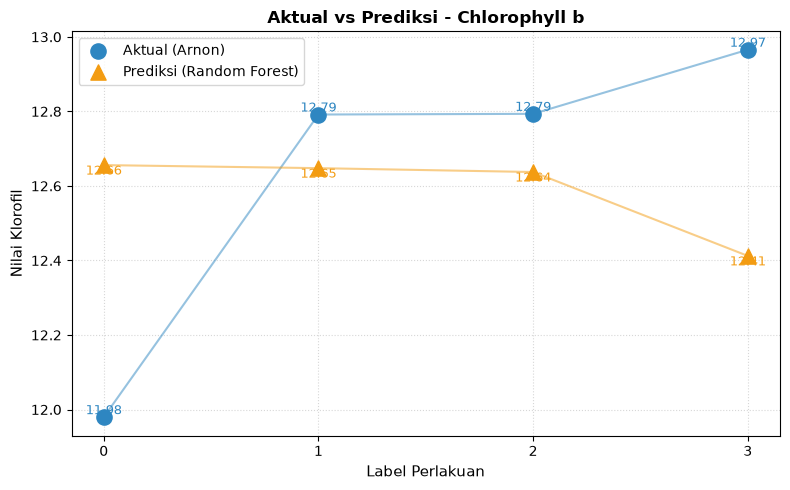

Klorofil_B disimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi_new\Scatter_PerLabel_Klorofil_B.png


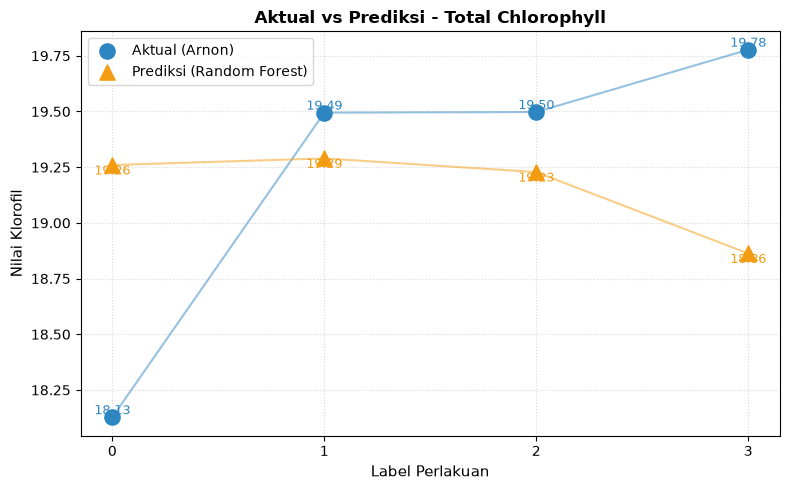

Total_Klorofil disimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi_new\Scatter_PerLabel_Total_Klorofil.png


In [76]:
# FOLDER_OUTPUT = "output_scatter"
# os.makedirs(FOLDER_OUTPUT, exist_ok=True)

def buat_scatter_plot_per_label(df_hasil):
    """
    Scatter Plot Aktual (Arnon) vs Prediksi Random Forest
    berdasarkan rata-rata setiap Label/Perlakuan.

    Input:
    ------
    df_hasil :
        DataFrame yang memiliki kolom:
        - Label atau Perlakuan
        - Klorofil_A
        - Pred_Klorofil_A
        - Klorofil_B
        - Pred_Klorofil_B
        - Total_Klorofil
        - Pred_Total_Klorofil
    """

    print("=" * 70)
    print("Scatter Plot Aktual vs Prediksi per Label")
    print("=" * 70)

    # ==========================
    # Tentukan kolom label
    # ==========================
    kolom_group = "Label" if "Label" in df_hasil.columns else "Perlakuan"

    # ==========================
    # Hitung rata-rata per label
    # ==========================
    df_label = (
        df_hasil
        .groupby(kolom_group, as_index=False)
        .agg({
            "Klorofil_A": "mean",
            "Pred_Klorofil_A": "mean",

            "Klorofil_B": "mean",
            "Pred_Klorofil_B": "mean",

            "Total_Klorofil": "mean",
            "Pred_Total_Klorofil": "mean"
        })
    )

    print("\nRata-rata tiap label:")
    print(df_label)

    # ==========================
    # Nama judul
    # ==========================
    label_judul = {
        "Klorofil_A": "Chlorophyll a",
        "Klorofil_B": "Chlorophyll b",
        "Total_Klorofil": "Total Chlorophyll"
    }

    pasangan_kolom = {
        "Klorofil_A": "Pred_Klorofil_A",
        "Klorofil_B": "Pred_Klorofil_B",
        "Total_Klorofil": "Pred_Total_Klorofil"
    }

    path_gambar = {}

    x_idx = np.arange(len(df_label))
    x_ticklabel = df_label[kolom_group].astype(str).tolist()

    # ==========================
    # Plot tiap target
    # ==========================
    for target, pred_col in pasangan_kolom.items():

        y_actual = df_label[target].values
        y_pred = df_label[pred_col].values

        plt.figure(figsize=(8,5))

        # Scatter aktual
        plt.scatter(
            x_idx,
            y_actual,
            color="#2E86C1",
            s=120,
            marker="o",
            label="Aktual (Arnon)",
            zorder=3
        )

        # Scatter prediksi
        plt.scatter(
            x_idx,
            y_pred,
            color="#F39C12",
            s=120,
            marker="^",
            label="Prediksi (Random Forest)",
            zorder=3
        )

        # Garis bantu
        plt.plot(
            x_idx,
            y_actual,
            color="#2E86C1",
            linewidth=1.5,
            alpha=0.5
        )

        plt.plot(
            x_idx,
            y_pred,
            color="#F39C12",
            linewidth=1.5,
            alpha=0.5
        )

        # Menampilkan nilai di atas titik
        for i in range(len(x_idx)):
            plt.text(
                x_idx[i],
                y_actual[i],
                f"{y_actual[i]:.2f}",
                color="#2E86C1",
                fontsize=9,
                ha="center",
                va="bottom"
            )

            plt.text(
                x_idx[i],
                y_pred[i],
                f"{y_pred[i]:.2f}",
                color="#F39C12",
                fontsize=9,
                ha="center",
                va="top"
            )

        plt.xticks(x_idx, x_ticklabel, fontsize=10)

        plt.xlabel("Label Perlakuan", fontsize=11)
        plt.ylabel("Nilai Klorofil", fontsize=11)

        plt.title(
            f"Aktual vs Prediksi - {label_judul[target]}",
            fontsize=12,
            fontweight="bold"
        )

        plt.grid(True, linestyle=":", alpha=0.5)
        plt.legend()
        plt.tight_layout()

        path_png = os.path.join(
            FOLDER_OUTPUT,
            f"Scatter_PerLabel_{target}.png"
        )

        plt.savefig(path_png, dpi=300)
        plt.show()
        plt.close()

        path_gambar[target] = path_png

        print(f"{target} disimpan di: {path_png}")

    return df_label, path_gambar

df_hasils = pd.read_excel("Hasil_Ekstraksi_new/hasil_prediksi_random_forest.xlsx")

df_per_label, gambar = buat_scatter_plot_per_label(df_hasils)


## `buat_histogram_exg`
Awalnya ini dibuat sebagai histogram (data dikelompokkan ke beberapa kotak rentang), tapi karena cuma ada 16 sampel, bentuk itu malah menyembunyikan identitas tiap tanaman. Jadi diganti jadi **bar chart per tanaman**, diurutkan dari ExG terkecil ke terbesar, warna batang menandakan kelompok perlakuan (0-3). Bentuk ini lebih jelas nunjukkan variasi ExG antar tanaman -- termasuk variasi ANTAR tanaman yang perlakuannya sama (yang jadi salah satu alasan kenapa R2 LOOCV bisa negatif).


In [77]:
def buat_histogram_exg(df_final):
    """Bar chart nilai ExG per tanaman (bukan histogram kotak lagi), diurutkan
    dari ExG terkecil ke terbesar, dan diwarnai per kelompok Perlakuan (0-3).
    Tujuannya biar tiap tanaman kelihatan jelas namanya + nilainya, sekaligus
    kelihatan apakah kelompok perlakuan yang sama cenderung ngumpul atau malah
    tersebar (yang ternyata tersebar -- itu insight penting buat Bab Discussion)."""
    print("=" * 70)
    print("Bar chart nilai ExG per tanaman, diurutkan dari terkecil ke terbesar")
    print("=" * 70)

    # Warna per kelompok Perlakuan (0-3) -- konsisten sama warna yang dipakai di laporan
    WARNA_PERLAKUAN = {0: "#2A78D6", 1: "#1BAF7A", 2: "#EDA100", 3: "#4A3AA7"}

    df_urut = df_final[["Nama_File", "Perlakuan", "ExG"]].sort_values("ExG").reset_index(drop=True)
    warna_batang = [WARNA_PERLAKUAN[int(p)] for p in df_urut["Perlakuan"]]

    plt.figure(figsize=(9, 4.8))
    plt.bar(df_urut["Nama_File"], df_urut["ExG"], color=warna_batang, width=0.6, zorder=3)
    plt.xticks(rotation=45, ha="right", fontsize=9)
    plt.title("Nilai Excess Green (ExG) per Tanaman, Diurutkan dari Terkecil ke Terbesar",
              fontsize=11, fontweight="bold")
    plt.xlabel("Sampel Tanaman")
    plt.ylabel("Nilai ExG")
    plt.grid(True, linestyle=":", alpha=0.5, axis="y", zorder=1)

    # Legend manual (warna -> nama Perlakuan), soalnya warnanya ditentukan per-batang
    from matplotlib.patches import Patch
    legend_items = [Patch(facecolor=WARNA_PERLAKUAN[p], label=f"Perlakuan {p}") for p in sorted(WARNA_PERLAKUAN)]
    plt.legend(handles=legend_items, loc="upper left", fontsize=9)
    plt.tight_layout()

    path_png = os.path.join(FOLDER_OUTPUT, "Histogram_ExG.png")
    plt.savefig(path_png, dpi=150)
    plt.show()
    plt.close()

    nilai_exg = df_final["ExG"].values
    print(f"  Rata-rata ExG   : {nilai_exg.mean():.4f}")
    print(f"  Std. deviasi ExG: {nilai_exg.std():.4f}")
    print(f"  Nilai minimum   : {nilai_exg.min():.4f} ({df_urut.iloc[0]['Nama_File']})")
    print(f"  Nilai maksimum  : {nilai_exg.max():.4f} ({df_urut.iloc[-1]['Nama_File']})")
    print(f"\n  Grafik ExG per tanaman tersimpan di: {path_png}\n")
    return path_png


In [78]:
def buat_histogram_exg(df_final) :
    """
    Bar chart nilai rata-rata ExG per Label/Perlakuan.
    """

    print("=" * 70)
    print("Bar chart rata-rata ExG per Label")
    print("=" * 70)

    # Warna tiap perlakuan
    WARNA_PERLAKUAN = {
        0: "#2A78D6",
        1: "#1BAF7A",
        2: "#EDA100",
        3: "#4A3AA7"
    }

    # Gunakan Label jika ada, jika tidak gunakan Perlakuan
    kolom_group = "Label" if "Label" in df_final.columns else "Perlakuan"

    # Hitung rata-rata ExG tiap label
    df_label = (
        df_final
        .groupby(kolom_group, as_index=False)
        .agg({"ExG": "mean"})
        .sort_values(kolom_group)
    )

    warna_batang = [
        WARNA_PERLAKUAN[int(label)]
        for label in df_label[kolom_group]
    ]

    plt.figure(figsize=(7,5))

    plt.bar(
        df_label[kolom_group].astype(str),
        df_label["ExG"],
        color=warna_batang,
        width=0.6,
        zorder=3
    )

    # Menampilkan nilai di atas batang
    for i, nilai in enumerate(df_label["ExG"]):
        plt.text(
            i,
            nilai,
            f"{nilai:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.title(
        "Rata-rata Nilai Excess Green (ExG) per Label",
        fontsize=12,
        fontweight="bold"
    )

    plt.xlabel("Label Perlakuan")
    plt.ylabel("Rata-rata Nilai ExG")

    plt.grid(True, axis="y", linestyle=":", alpha=0.5, zorder=1)

    from matplotlib.patches import Patch

    legend_items = [
        Patch(facecolor=WARNA_PERLAKUAN[i], label=f"Label {i}")
        for i in sorted(WARNA_PERLAKUAN)
    ]

    plt.legend(handles=legend_items, fontsize=9)
    plt.tight_layout()

    path_png = os.path.join(
        FOLDER_OUTPUT,
        "Histogram_ExG_PerLabel.png"
    )

    plt.savefig(path_png, dpi=300)
    plt.show()
    plt.close()

    # Statistik
    nilai_exg = df_label["ExG"].values

    print(f"Rata-rata ExG keseluruhan : {nilai_exg.mean():.4f}")
    print(f"Std. deviasi             : {nilai_exg.std():.4f}")
    print(f"Minimum                  : {nilai_exg.min():.4f}")
    print(f"Maksimum                 : {nilai_exg.max():.4f}")

    print(f"\nGrafik disimpan di: {path_png}")

    return df_label, path_png

Bar chart rata-rata ExG per Label


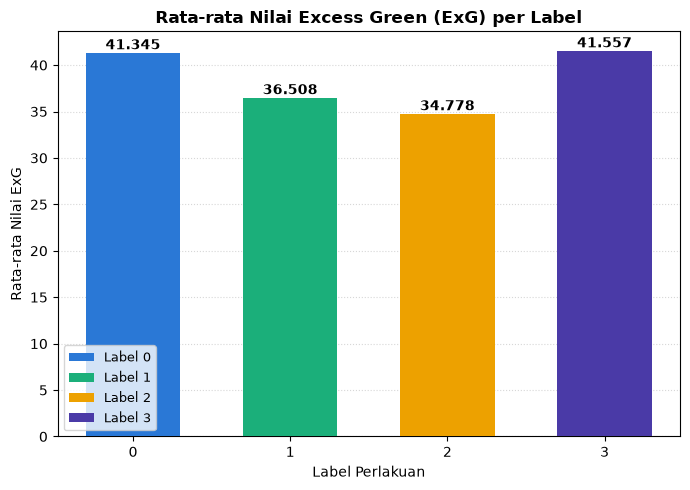

Rata-rata ExG keseluruhan : 38.5467
Std. deviasi             : 2.9686
Minimum                  : 34.7777
Maksimum                 : 41.5565

Grafik disimpan di: C:\Users\Balqoz\skripsiku\Hasil_Ekstraksi_new\Histogram_ExG_PerLabel.png


In [79]:
# Menampilkan bar chart ExG per tanaman (diurutkan, diwarnai per Perlakuan)
path_histogram_exg = buat_histogram_exg(df_hasils)


## `simpan_model_final`
Training ulang modelnya sekali lagi, tapi kali ini pakai SELURUH 16 data (nggak ada yang disisihkan seperti di LOOCV), lalu disimpan jadi file `.pkl`. Model final inilah yang dipanggil sama `app.py` waktu ada yang minta prediksi lewat web.


In [80]:
TARGETS = ["Klorofil_A", "Klorofil_B", "Total_Klorofil"] 

def simpan_model_final(df_final):
    """Model yang dipakai di LOOCV tadi cuma buat NGUKUR performa -- modelnya
    dibuang lagi tiap iterasi. Model yang benar-benar dipakai buat prediksi di
    web adalah model baru ini, yang dilatih dari SEMUA 16 sampel sekaligus
    (biar makin banyak "pengalaman" yang dipelajari sebelum dipakai produksi)."""
    print("=" * 70)
    print("Training model final (pakai seluruh 16 data) & simpan .pkl")
    print("=" * 70)

    X = df_final[FITUR].values
    nama_file_model = {"Klorofil_A": "model_rf_a.pkl",
                        "Klorofil_B": "model_rf_b.pkl",
                        "Total_Klorofil": "model_rf_total.pkl"}

    for target in TARGETS:
        y = df_final[target].values
        model = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
        model.fit(X, y)
        joblib.dump(model, nama_file_model[target])
        print(f"  Model untuk {target} disimpan di: {nama_file_model[target]}")

    print(f"\n>> Fitur yang dipakai model (URUTAN INI HARUS SAMA saat prediksi di app.py):")
    print(f"   {FITUR}\n")


In [81]:
df_hasils

,Nama_File,Perlakuan,Tanaman_Ke,R,G,B,IR,ExG,Klorofil_A,Klorofil_B,Total_Klorofil,Pred_Klorofil_A,Pred_Klorofil_B,Pred_Total_Klorofil
0,HH01,0,1,148.693333,150.792000,117.351200,71.880000,35.539467,6.186804,11.979488,18.127974,6.744673,12.801189,19.510251
1,HH02,0,2,143.643564,147.645545,111.587129,89.643564,40.060396,6.186804,11.979488,18.127974,6.629750,12.635892,19.196917
2,HH03,0,3,143.641026,146.476923,109.260000,69.858974,40.052821,6.186804,11.979488,18.127974,6.538071,12.519162,19.019443
3,HH04,0,4,130.722222,136.500000,92.551389,68.111111,49.726389,6.186804,11.979488,18.127974,6.662940,12.667413,19.312200
4,HH11,1,1,151.890244,152.248780,114.314146,75.865854,38.293171,6.738629,12.791618,19.494740,6.637545,12.659466,19.318762
5,HH12,1,2,146.933333,150.376000,116.044267,74.973333,37.774400,6.738629,12.791618,19.494740,6.657707,12.687389,19.349310
6,HH13,1,3,145.550562,148.325843,114.868989,68.685393,36.232135,6.738629,12.791618,19.494740,6.634293,12.568647,19.209571
7,HH14,1,4,153.057377,154.822951,122.856721,70.090164,33.731803,6.738629,12.791618,19.494740,6.663130,12.675287,19.279975
8,HH21,2,1,152.852941,154.929412,123.797059,91.225490,33.208824,6.739630,12.793440,19.497562,6.674031,12.704825,19.348717
9,HH22,2,2,150.090909,153.772727,124.913182,93.681818,32.541364,6.739630,12.793440,19.497562,6.641022,12.664637,19.280746


In [82]:
# Training model final (pakai semua 16 data) lalu simpan ke .pkl
simpan_model_final(df_hasils)


Training model final (pakai seluruh 16 data) & simpan .pkl
  Model untuk Klorofil_A disimpan di: model_rf_a.pkl
  Model untuk Klorofil_B disimpan di: model_rf_b.pkl
  Model untuk Total_Klorofil disimpan di: model_rf_total.pkl

>> Fitur yang dipakai model (URUTAN INI HARUS SAMA saat prediksi di app.py):
   ['R', 'G', 'B', 'IR', 'ExG']

